In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/PS_20174392719_1491204439457_log.csv")
df["hour"] = df["step"] % 24
print(df.shape, "nulls:", df.isnull().sum().sum())
df.head()

(6362620, 12) nulls: 0


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1


isFraud
0    6354407
1       8213
Name: count, dtype: int64
fraud rate: 0.1291%
imbalance 1:774


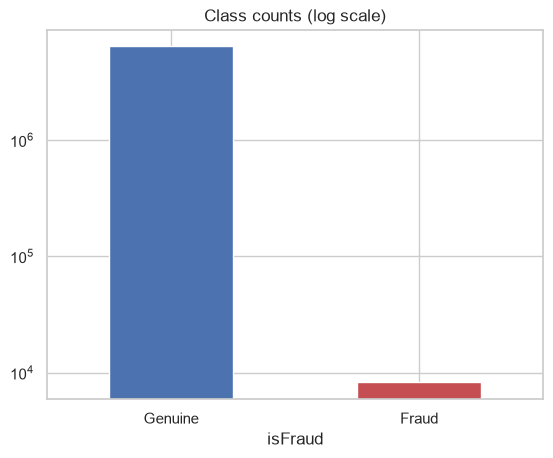

In [2]:
vc = df["isFraud"].value_counts()
print(vc)
print(f"fraud rate: {df.isFraud.mean():.4%}")
print(f"imbalance 1:{vc[0]/vc[1]:.0f}")

ax = vc.plot(kind="bar", logy=True, color=["#4c72b0", "#c44e52"])
ax.set_xticklabels(["Genuine", "Fraud"], rotation=0)
ax.set_title("Class counts (log scale)")
plt.savefig("../reports/01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

                n  fraud  fraud_rate
type                                
CASH_IN   1399284      0    0.000000
CASH_OUT  2237500   4116    0.001840
DEBIT       41432      0    0.000000
PAYMENT   2151495      0    0.000000
TRANSFER   532909   4097    0.007688


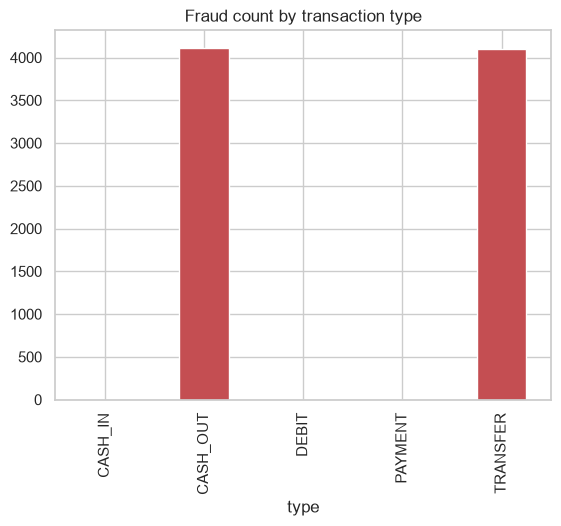

In [3]:
t = df.groupby("type").agg(n=("isFraud","size"), fraud=("isFraud","sum"))
t["fraud_rate"] = t.fraud / t.n
print(t)

t["fraud"].plot(kind="bar", color="#c44e52")
plt.title("Fraud count by transaction type")
plt.savefig("../reports/02_fraud_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

             count          mean           std   min          25%        50%  \
isFraud                                                                        
0        2762196.0  3.141155e+05  8.771441e+05  0.01   82908.2325  171034.46   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.3300  441423.44   

                 75%          max  
isFraud                            
0         305994.185  92445516.64  
1        1517771.480  10000000.00  


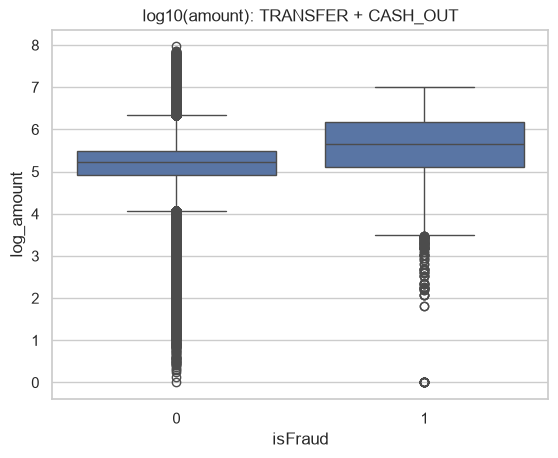

In [4]:
sub = df[df.type.isin(["TRANSFER","CASH_OUT"])]
print(sub.groupby("isFraud").amount.describe())

sub2 = sub.assign(log_amount=np.log10(sub.amount + 1))
sns.boxplot(data=sub2, x="isFraud", y="log_amount")
plt.title("log10(amount): TRANSFER + CASH_OUT")
plt.savefig("../reports/03_amount.png", dpi=150, bbox_inches="tight")
plt.show()

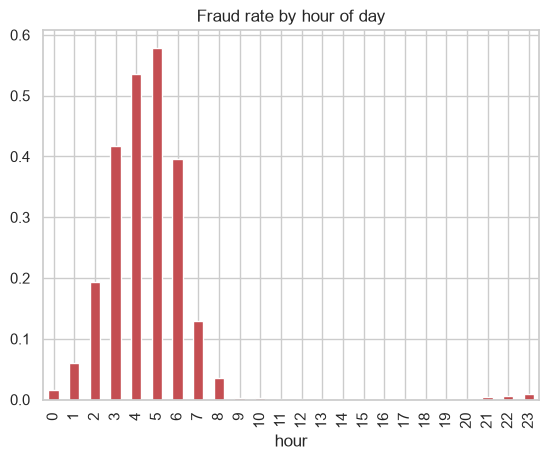

In [5]:
h = sub.groupby("hour").isFraud.agg(["sum","size"])
h["rate"] = h["sum"] / h["size"]
h["rate"].plot(kind="bar", color="#c44e52")
plt.title("Fraud rate by hour of day")
plt.savefig("../reports/04_hour.png", dpi=150, bbox_inches="tight")
plt.show()

fraud: amount == oldbalanceOrg: 0.9782052843053696
fraud: newbalanceOrig == 0: 0.9805186898818946
genuine: amount == oldbalanceOrg: 0.0
                        Genuine  Fraud
col_0                                 
partial (<1)              0.098  0.018
full drain (=1)           0.001  0.976
more than balance (>1)    0.426  0.000
balance was 0             0.474  0.005


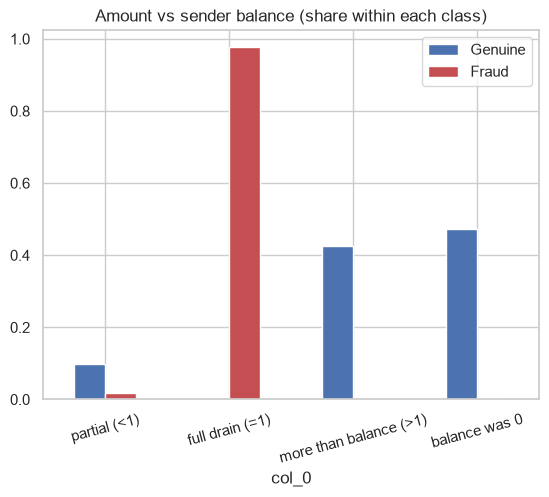

In [7]:
f = sub[sub.isFraud==1]; g = sub[sub.isFraud==0]
print("fraud: amount == oldbalanceOrg:", (f.amount==f.oldbalanceOrg).mean())
print("fraud: newbalanceOrig == 0:", (f.newbalanceOrig==0).mean())
print("genuine: amount == oldbalanceOrg:", (g.amount==g.oldbalanceOrg).mean())

r = sub.amount / sub.oldbalanceOrg.replace(0, np.nan)
cat = pd.cut(r, [-np.inf, 0.99, 1.01, np.inf], labels=["partial (<1)", "full drain (=1)", "more than balance (>1)"])
cat = cat.cat.add_categories("balance was 0").fillna("balance was 0")
tab = pd.crosstab(sub.isFraud, cat, normalize="index").T
tab.columns = ["Genuine", "Fraud"]
print(tab.round(3))
tab.plot(kind="bar", color=["#4c72b0", "#c44e52"])
plt.title("Amount vs sender balance (share within each class)")
plt.xticks(rotation=15)
plt.savefig("../reports/05_drain.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("rows:", len(df))
print("unique senders:", df.nameOrig.nunique())
print("unique receivers:", df.nameDest.nunique())
print("isFlaggedFraud=1 rows:", df.isFlaggedFraud.sum())

rows: 6362620
unique senders: 6353307
unique receivers: 2722362
isFlaggedFraud=1 rows: 16


## Findings
- 6.36M transactions, 8,213 fraud (0.129%), imbalance 1:774. Accuracy is useless; use precision, recall, PR-AUC.
- Fraud occurs only in TRANSFER (rate 0.77%) and CASH_OUT (0.18%). Other types have zero fraud.
- Fraud amounts are larger: mean 1.47M vs 314K genuine (TRANSFER + CASH_OUT), capped at 10M. Wide overlap, amount alone insufficient.
- Fraud spikes at hours 3-5 (40-58% of txns in those hours), near zero at hours 9-20. Genuine volume drops at night, fraud stays flat.
- 97.6% of fraud drains the sender's full balance; 0.1% of genuine does. 98% end with newbalanceOrig = 0.
- Genuine data is unrealistic: 47% have sender balance 0, 43% send more than balance (simulator artifact).
- Senders almost never repeat (6.35M unique of 6.36M rows): per-sender history features are weak here; use receiver history.
- isFlaggedFraud fires on only 16 rows: dropped.